INFO:root:Downloading graph for Sunshine Hills...
INFO:root:Using filter: ['name']['highway']['highway' = 'trunk']['expressway' != 'yes']['motorroad' != 'yes']['foot' != 'no']
INFO:root:Using filter: ['name']['highway']['highway' !~ 'bridleway']['highway' !~ 'bus_guideway']['highway' !~ 'bus_stop']['highway' !~ 'busway']['highway' !~ 'construction']['highway' !~ 'corridor']['highway' !~ 'cycleway']['highway' !~ 'elevator']['highway' !~ 'escape']['highway' !~ 'footway']['highway' !~ 'motorway']['highway' !~ 'motorway_junction']['highway' !~ 'motorway_link']['highway' !~ 'path']['highway' !~ 'planned']['highway' !~ 'platform']['highway' !~ 'proposed']['highway' !~ 'raceway']['highway' !~ 'razed']['highway' !~ 'rest_area']['highway' !~ 'services']['highway' !~ 'steps']['highway' !~ 'trunk']['highway' !~ 'via_ferrata']['access' !~ 'customers']['access' !~ '^(no)$']['access' !~ 'private']['aeroway' !~ 'jet_bridge']['amenity' !~ 'theatre']['amenity' !~ 'weighbridge']['area' !~ 'yes']['expres

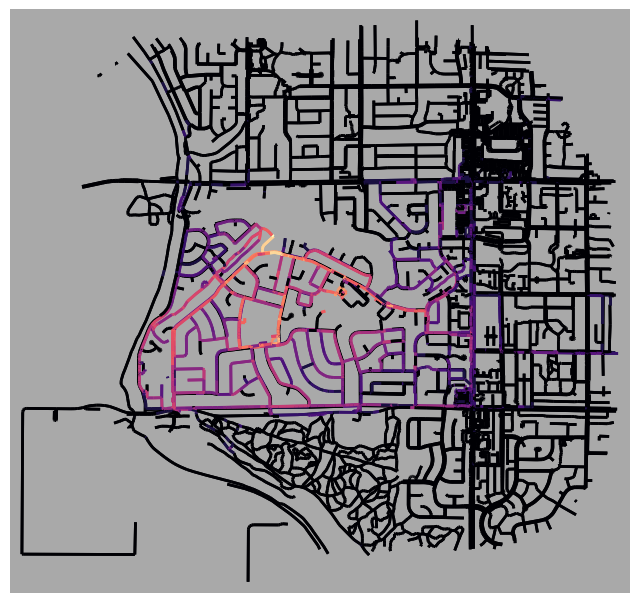

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [1]:
import logging
import pickle

import geopandas as gpd
import numpy as np
import pandas as pd
import osmnx as ox
import networkx as nx

from graph.download import download_cs_graph, download_walk_graph
from graph.strava import create_routes
from graph.graph import get_routes_in_area, to_digraph, graph_to_gdf, subgraph_from_gdf_mask, add_visited_counts
from matching.candidate import get_candidate_idxs, get_candidate_df
from matching.match import Matcher


logging.basicConfig(level=logging.INFO)

G, gdf = download_cs_graph("Sunshine Hills")
G2, gdf2 = download_walk_graph(gdf)
G = to_digraph(G)
G2 = to_digraph(G2)
# create_routes("Jess")
c_gdf = graph_to_gdf(G2)
c_gdf = ox.projection.project_gdf(c_gdf)
gdf = ox.projection.project_gdf(gdf)
with open("matched_routes_Jess.pkl", "rb") as file:
    matched_dict = pickle.load(file)
matcher = Matcher(matched_routes=matched_dict)
for route_id, route in get_routes_in_area(gdf, "routes_Jess.pkl"):
    logging.info(f"Route {route_id} has {len(route)} points")
    if route_id in matcher.matched_routes:
        logging.info(f"Route {route_id} already matched with {len(matcher.matched_routes[route_id])} edges, skipping")
        continue
    idxs = get_candidate_idxs(c_gdf, ox.projection.project_gdf(gdf2).geometry, route, 25)
    df = get_candidate_df(c_gdf, route, idxs)
    mask = pd.concat([df.geometry_obs, df.geometry]).drop_duplicates(ignore_index=True)
    G_route = subgraph_from_gdf_mask(G2, c_gdf, mask, 250)
    logging.info(f"Route {route_id} graph has {G_route.number_of_nodes()} nodes and {G_route.number_of_edges()} edges")
    trellis = matcher.create_trellis(df)
    preds = matcher.viterbi_search(G_route, trellis)
    edges = matcher.get_path_edges(G_route, trellis, preds, route_id=route_id)
    logging.info(
        f"Matched route {route_id} has {len([node for node in preds.keys() if node.startswith('gap')])} gaps and {len(edges)} edges"
    )
add_visited_counts(G2, matcher.matched_routes)
colors = ox.plot.get_edge_colors_by_attr(G2, "visited", cmap="magma")
ox.plot.plot_graph(nx.MultiDiGraph(G2), edge_color=colors, node_size=0, edge_linewidth=2.0, bgcolor="darkgrey")
# G = to_digraph(G)
# add_visited_counts(G, "routes_Jess.pkl")


In [2]:
matched_dict = matcher.matched_routes

with open("matched_routes_Jess.pkl", "wb") as file:
    pickle.dump(matched_dict, file, protocol=pickle.HIGHEST_PROTOCOL)